# 05 — Deep Learning with Temporal Convolutional Network (TCN)

Two tasks matching our classical ML methodology:
1. **Owner authentication** (binary: owner vs non-owner) — trained on normal session 1, tested on normal session 2
2. **Cross-context robustness** — same model tested on crowded session 2 without retraining

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

ROOT = Path('.').resolve()
WIND = ROOT / 'windowed_data'
RES = ROOT / 'results'
FIG = ROOT / 'figures'
RES.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
X_train = np.load(WIND / 'X_train.npy')
X_test = np.load(WIND / 'X_test.npy')
meta_train = pd.read_csv(WIND / 'meta_train.csv')
meta_test = pd.read_csv(WIND / 'meta_test.csv')

print('Full dataset shapes:')
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"  Train contexts: {meta_train['context'].value_counts().to_dict()}")
print(f"  Test contexts: {meta_test['context'].value_counts().to_dict()}")

Full dataset shapes:
  X_train: (2498, 200, 6), X_test: (1770, 200, 6)
  Train contexts: {'normal': 1432, 'crowded': 1066}
  Test contexts: {'crowded': 1054, 'normal': 716}


In [3]:
OWNER = 'Pedro'

train_normal_idx = (meta_train['context'] == 'normal').values
test_normal_idx = (meta_test['context'] == 'normal').values
test_crowded_idx = (meta_test['context'] == 'crowded').values

y_owner_train = (meta_train['label_person'] == OWNER).astype(int).values
y_owner_test = (meta_test['label_person'] == OWNER).astype(int).values

# Task 1: Owner authentication — train on normal session 1, test on normal session 2
X_train_auth = X_train[train_normal_idx]
y_train_auth = y_owner_train[train_normal_idx]
X_test_auth = X_test[test_normal_idx]
y_test_auth = y_owner_test[test_normal_idx]

print('=== Task 1: Owner Authentication ===')
print(f'Train (normal s1): n={len(y_train_auth)}, owner={y_train_auth.sum()}, non-owner={(1-y_train_auth).sum()}')
print(f'Test  (normal s2): n={len(y_test_auth)}, owner={y_test_auth.sum()}, non-owner={(1-y_test_auth).sum()}')

=== Task 1: Owner Authentication ===
Train (normal s1): n=1432, owner=358, non-owner=1074
Test  (normal s2): n=716, owner=179, non-owner=537


In [4]:
# Task 2: Cross-context robustness — same training data, tested on crowded session 2
X_test_crowded = X_test[test_crowded_idx]
y_test_crowded = y_owner_test[test_crowded_idx]

print('=== Task 2: Cross-context Robustness ===')
print(f'Train (normal s1):   n={len(y_train_auth)}, owner={y_train_auth.sum()}, non-owner={(1-y_train_auth).sum()}')
print(f'Test  (crowded s2):  n={len(y_test_crowded)}, owner={y_test_crowded.sum()}, non-owner={(1-y_test_crowded).sum()}')

=== Task 2: Cross-context Robustness ===
Train (normal s1):   n=1432, owner=358, non-owner=1074
Test  (crowded s2):  n=1054, owner=178, non-owner=876


In [5]:
class TemporalConvNet(nn.Module):
    def __init__(self, num_channels=64, kernel_size=5, dropout=0.3, num_classes=2):
        super().__init__()
        self.num_channels = num_channels
        
        # Input: (batch, 6, 200) channels x timesteps
        layers = []
        num_levels = 3
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_ch = 6 if i == 0 else num_channels
            out_ch = num_channels
            layers.append(nn.Conv1d(in_ch, out_ch, kernel_size, padding=(kernel_size-1)*dilation_size,
                                     dilation=dilation_size))
            layers.append(nn.BatchNorm1d(out_ch))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        
        self.network = nn.Sequential(*layers)
        self.fc1 = nn.Linear(num_channels, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        y = self.network(x)
        y = y.mean(dim=2)
        y = self.fc1(y)
        y = torch.relu(y)
        y = self.dropout(y)
        y = self.fc2(y)
        return y


print('TCN model defined. Total params:', sum(p.numel() for p in TemporalConvNet().parameters()))

TCN model defined. Total params: 47746


In [6]:
def train_model(X_train, y_train, X_test, y_test, epochs=100, batch_size=32, lr=1e-3):
    X_tr = torch.from_numpy(X_train).float().transpose(1, 2)
    y_tr = torch.from_numpy(y_train).long()
    X_te = torch.from_numpy(X_test).float().transpose(1, 2)
    y_te = torch.from_numpy(y_test).long()
    
    train_ds = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    model = TemporalConvNet(num_channels=64, kernel_size=5, dropout=0.3, 
                            num_classes=len(np.unique(y_train))).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    best_test_acc = 0
    best_model_state = model.state_dict().copy()
    history = {'train_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
        train_loss /= len(y_tr)
        history['train_loss'].append(train_loss)
        
        model.eval()
        with torch.no_grad():
            logits_te = model(X_te.to(device))
            pred_te = logits_te.argmax(dim=1).cpu().numpy()
            acc_te = accuracy_score(y_te.numpy(), pred_te)
            history['test_acc'].append(acc_te)
            if acc_te > best_test_acc:
                best_test_acc = acc_te
                best_model_state = model.state_dict().copy()
        
        scheduler.step(train_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f}, test_acc={acc_te:.4f}")
    
    model.load_state_dict(best_model_state)
    
    model.eval()
    with torch.no_grad():
        logits_tr = model(X_tr.to(device))
        logits_te = model(X_te.to(device))
        pred_tr = logits_tr.argmax(dim=1).cpu().numpy()
        pred_te = logits_te.argmax(dim=1).cpu().numpy()
        if len(np.unique(y_train)) == 2:
            probs_te = torch.softmax(logits_te, dim=1).cpu().numpy()
        else:
            probs_te = None
    
    return pred_tr, pred_te, probs_te, history, model


def predict_with_model(model, X):
    X_t = torch.from_numpy(X).float().transpose(1, 2).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        pred = logits.argmax(dim=1).cpu().numpy()
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return pred, probs


print('Training function defined.')

Training function defined.


In [7]:
def evaluate_binary(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba[:, 1]) if y_proba is not None else np.nan,
    }


print('\n=== Training Task 1: Owner Authentication ===')
pred_tr_auth, pred_te_auth, probs_te_auth, hist_auth, model_auth = train_model(
    X_train_auth, y_train_auth, X_test_auth, y_test_auth, epochs=100, batch_size=32
)

metrics_auth = evaluate_binary(y_test_auth, pred_te_auth, probs_te_auth)
print(f"\nOwner authentication — Test:")
print(f"  Acc={metrics_auth['accuracy']:.4f}, F1={metrics_auth['f1']:.4f}, "
      f"Prec={metrics_auth['precision']:.4f}, Rec={metrics_auth['recall']:.4f}, "
      f"AUC={metrics_auth['roc_auc']:.4f}")
print(f"Baseline (RF): Acc=1.000, F1=1.000, Prec=1.000, Rec=1.000, AUC=1.000")


=== Training Task 1: Owner Authentication ===
  Epoch 20/100: train_loss=0.0003, test_acc=1.0000
  Epoch 40/100: train_loss=0.0000, test_acc=1.0000
  Epoch 60/100: train_loss=0.0000, test_acc=1.0000
  Epoch 80/100: train_loss=0.0001, test_acc=1.0000
  Epoch 100/100: train_loss=0.0000, test_acc=1.0000

Owner authentication — Test:
  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000
Baseline (RF): Acc=1.000, F1=1.000, Prec=1.000, Rec=1.000, AUC=1.000


In [8]:
print('\n=== Training Task 2: Cross-context Robustness ===')
print('Same model from Task 1 (trained on normal), tested on crowded without retraining\n')

pred_te_crowded, probs_te_crowded = predict_with_model(model_auth, X_test_crowded)

metrics_normal = metrics_auth
metrics_crowded = evaluate_binary(y_test_crowded, pred_te_crowded, probs_te_crowded)

print(f"Normal test:  Acc={metrics_normal['accuracy']:.4f}, F1={metrics_normal['f1']:.4f}, "
      f"Prec={metrics_normal['precision']:.4f}, Rec={metrics_normal['recall']:.4f}")
print(f"Crowded test: Acc={metrics_crowded['accuracy']:.4f}, F1={metrics_crowded['f1']:.4f}, "
      f"Prec={metrics_crowded['precision']:.4f}, Rec={metrics_crowded['recall']:.4f}")
print(f"\nBaseline (RF): normal=1.000/1.000, crowded=0.898/0.651")


=== Training Task 2: Cross-context Robustness ===
Same model from Task 1 (trained on normal), tested on crowded without retraining

Normal test:  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000
Crowded test: Acc=0.8027, F1=0.6312, Prec=0.4611, Rec=1.0000

Baseline (RF): normal=1.000/1.000, crowded=0.898/0.651


In [9]:
dl_results = pd.DataFrame([
    {'task': 'Owner authentication', 'accuracy': metrics_auth['accuracy'],
     'f1': metrics_auth['f1'], 'precision': metrics_auth['precision'],
     'recall': metrics_auth['recall'], 'roc_auc': metrics_auth['roc_auc'],
     'model': 'TCN'},
    {'task': 'Cross-context robustness', 'accuracy': metrics_normal['accuracy'],
     'f1': metrics_normal['f1'], 'precision': metrics_normal['precision'],
     'recall': metrics_normal['recall'], 'roc_auc': metrics_normal['roc_auc'],
     'model': 'TCN', 'subset': 'normal_test'},
    {'task': 'Cross-context robustness', 'accuracy': metrics_crowded['accuracy'],
     'f1': metrics_crowded['f1'], 'precision': metrics_crowded['precision'],
     'recall': metrics_crowded['recall'], 'roc_auc': metrics_crowded['roc_auc'],
     'model': 'TCN', 'subset': 'crowded_test'},
])

print('\n=== Deep Learning vs Classical ML ===')
print(f"\n{'Task':<35} {'Model':<8} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'AUC':>6}")
print('-' * 80)
print(f"{'Owner authentication':<35} {'RF':<8} {'1.000':>6} {'1.000':>6} {'1.000':>6} {'1.000':>6} {'1.000':>6}")
print(f"{'Owner authentication':<35} {'TCN':<8} {metrics_auth['accuracy']:>6.3f} {metrics_auth['f1']:>6.3f} {metrics_auth['precision']:>6.3f} {metrics_auth['recall']:>6.3f} {metrics_auth['roc_auc']:>6.3f}")
print(f"{'Cross-context (normal test)':<35} {'RF':<8} {'1.000':>6} {'1.000':>6} {'1.000':>6} {'1.000':>6}")
print(f"{'Cross-context (normal test)':<35} {'TCN':<8} {metrics_normal['accuracy']:>6.3f} {metrics_normal['f1']:>6.3f} {metrics_normal['precision']:>6.3f} {metrics_normal['recall']:>6.3f}")
print(f"{'Cross-context (crowded test)':<35} {'RF':<8} {'0.898':>6} {'0.651':>6} {'0.775':>6} {'0.562':>6}")
print(f"{'Cross-context (crowded test)':<35} {'TCN':<8} {metrics_crowded['accuracy']:>6.3f} {metrics_crowded['f1']:>6.3f} {metrics_crowded['precision']:>6.3f} {metrics_crowded['recall']:>6.3f}")

dl_results.to_csv(RES / 'deeplearning_results.csv', index=False)


=== Deep Learning vs Classical ML ===

Task                                Model       Acc     F1   Prec    Rec    AUC
--------------------------------------------------------------------------------
Owner authentication                RF        1.000  1.000  1.000  1.000  1.000
Owner authentication                TCN       1.000  1.000  1.000  1.000  1.000
Cross-context (normal test)         RF        1.000  1.000  1.000  1.000
Cross-context (normal test)         TCN       1.000  1.000  1.000  1.000
Cross-context (crowded test)        RF        0.898  0.651  0.775  0.562
Cross-context (crowded test)        TCN       0.803  0.631  0.461  1.000


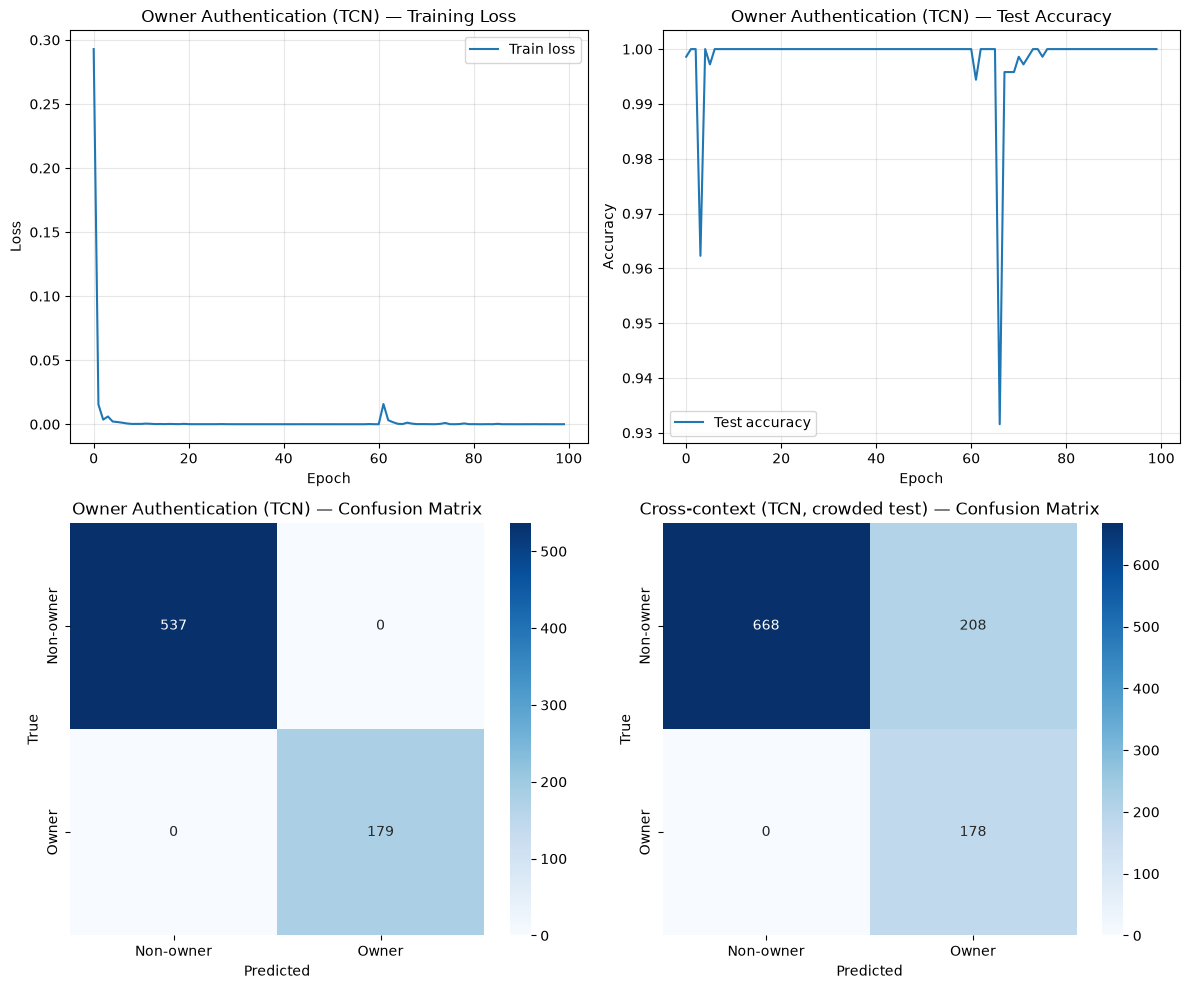

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(hist_auth['train_loss'], label='Train loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Owner Authentication (TCN) — Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(hist_auth['test_acc'], label='Test accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Owner Authentication (TCN) — Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

cm_auth = confusion_matrix(y_test_auth, pred_te_auth)
sns.heatmap(cm_auth, annot=True, fmt='d', ax=axes[1, 0], cmap='Blues',
            xticklabels=['Non-owner', 'Owner'], yticklabels=['Non-owner', 'Owner'])
axes[1, 0].set_title('Owner Authentication (TCN) — Confusion Matrix')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_xlabel('Predicted')

cm_crowded = confusion_matrix(y_test_crowded, pred_te_crowded)
sns.heatmap(cm_crowded, annot=True, fmt='d', ax=axes[1, 1], cmap='Blues',
            xticklabels=['Non-owner', 'Owner'], yticklabels=['Non-owner', 'Owner'])
axes[1, 1].set_title('Cross-context (TCN, crowded test) — Confusion Matrix')
axes[1, 1].set_ylabel('True')
axes[1, 1].set_xlabel('Predicted')

fig.tight_layout()
fig.savefig(FIG / 'fig15_tcn_results.png', dpi=150)
plt.show()

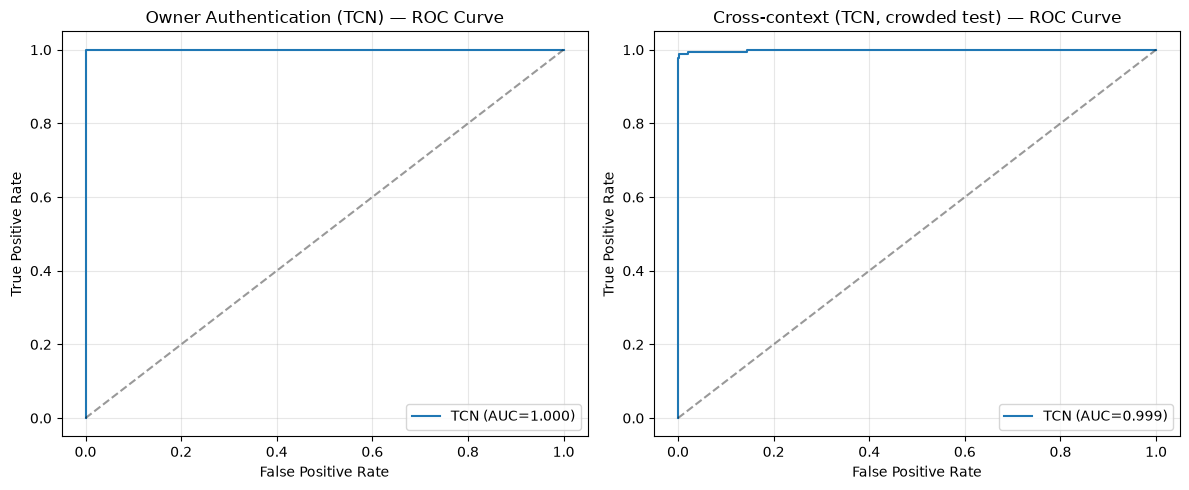

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_auth, tpr_auth, _ = roc_curve(y_test_auth, probs_te_auth[:, 1])
auc_auth = metrics_auth['roc_auc']
axes[0].plot(fpr_auth, tpr_auth, label=f'TCN (AUC={auc_auth:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Owner Authentication (TCN) — ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fpr_crowded, tpr_crowded, _ = roc_curve(y_test_crowded, probs_te_crowded[:, 1])
auc_crowded = metrics_crowded['roc_auc']
axes[1].plot(fpr_crowded, tpr_crowded, label=f'TCN (AUC={auc_crowded:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Cross-context (TCN, crowded test) — ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG / 'fig16_tcn_roc.png', dpi=150)
plt.show()

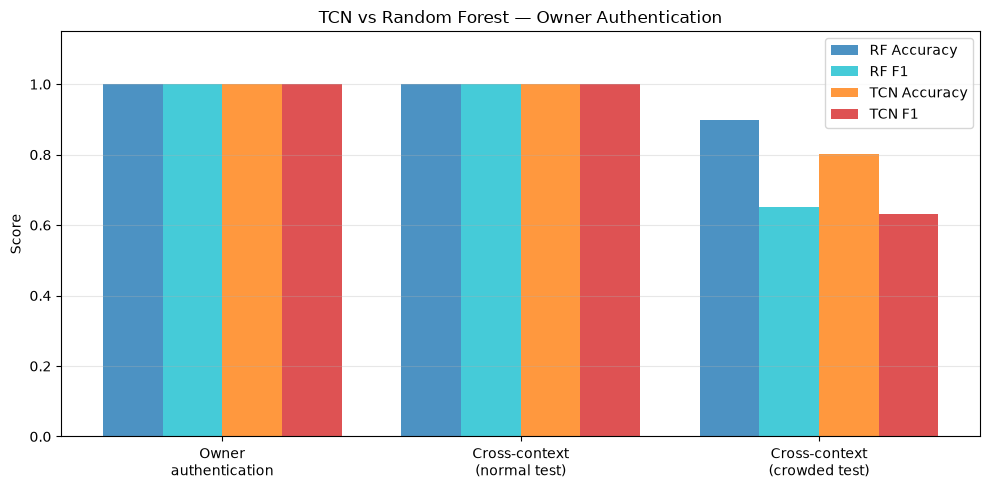

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

tasks = ['Owner\nauthentication', 'Cross-context\n(normal test)', 'Cross-context\n(crowded test)']
classical_accs = [1.000, 1.000, 0.898]
classical_f1s = [1.000, 1.000, 0.651]
dl_accs = [metrics_auth['accuracy'], metrics_normal['accuracy'], metrics_crowded['accuracy']]
dl_f1s = [metrics_auth['f1'], metrics_normal['f1'], metrics_crowded['f1']]

x = np.arange(len(tasks))
width = 0.2

ax.bar(x - 1.5*width, classical_accs, width, label='RF Accuracy', alpha=0.8, color='tab:blue')
ax.bar(x - 0.5*width, classical_f1s, width, label='RF F1', alpha=0.8, color='tab:cyan')
ax.bar(x + 0.5*width, dl_accs, width, label='TCN Accuracy', alpha=0.8, color='tab:orange')
ax.bar(x + 1.5*width, dl_f1s, width, label='TCN F1', alpha=0.8, color='tab:red')

ax.set_ylabel('Score')
ax.set_title('TCN vs Random Forest — Owner Authentication')
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.set_ylim([0, 1.15])
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIG / 'fig17_tcn_vs_classical.png', dpi=150)
plt.show()

In [13]:
print('\n' + '='*60)
print('TEMPORAL CONVOLUTIONAL NETWORK (TCN) RESULTS SUMMARY')
print('='*60)
print(f"\nTask 1: Owner Authentication (normal session 2 test)")
print(f"  TCN:      Acc={metrics_auth['accuracy']:.4f}, F1={metrics_auth['f1']:.4f}, "
      f"Prec={metrics_auth['precision']:.4f}, Rec={metrics_auth['recall']:.4f}, "
      f"AUC={metrics_auth['roc_auc']:.4f}")
print(f"  Best ML:  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000 (RF)")

print(f"\nTask 2: Cross-context Robustness")
print(f"  Normal test:")
print(f"    TCN:    Acc={metrics_normal['accuracy']:.4f}, F1={metrics_normal['f1']:.4f}, "
      f"Prec={metrics_normal['precision']:.4f}, Rec={metrics_normal['recall']:.4f}")
print(f"    RF:     Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000")
print(f"  Crowded test:")
print(f"    TCN:    Acc={metrics_crowded['accuracy']:.4f}, F1={metrics_crowded['f1']:.4f}, "
      f"Prec={metrics_crowded['precision']:.4f}, Rec={metrics_crowded['recall']:.4f}")
print(f"    RF:     Acc=0.8985, F1=0.6515, Prec=0.7750, Rec=0.5620")

print(f"\nAll results saved to {RES}/")


TEMPORAL CONVOLUTIONAL NETWORK (TCN) RESULTS SUMMARY

Task 1: Owner Authentication (normal session 2 test)
  TCN:      Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000
  Best ML:  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000 (RF)

Task 2: Cross-context Robustness
  Normal test:
    TCN:    Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000
    RF:     Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000
  Crowded test:
    TCN:    Acc=0.8027, F1=0.6312, Prec=0.4611, Rec=1.0000
    RF:     Acc=0.8985, F1=0.6515, Prec=0.7750, Rec=0.5620

All results saved to C:\Users\Jun\Documents\ML4QS\Experiment\results/
